# Clasical ML model selection - Derived features - 40 selected

Just like in 06_classification_baseline.ipynb, I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

Run with all features...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel
from core.utils import extract_subject_id
from core.evaluation import model_test_summary, pick_threshold
from core.model_selection import split_train_test_set
from core.evaluation import SklearnAPIPredictor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
SAVE_MODEL = False
MODEL_NAME = "baseline_derived_40_final"

In [3]:
X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_DERIVED_STANDARDISED_40, index_col=0)
y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_DERIVED_STANDARDISED, index_col=0)

X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_DERIVED_STANDARDISED_40, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_DERIVED_STANDARDISED, index_col=0)

X_val = pd.read_csv(c.RICKD_MODEL_1_X_VAL_DERIVED_STANDARDISED_40, index_col=0)
y_val = pd.read_csv(c.RICKD_MODEL_1_Y_VAL_DERIVED_STANDARDISED, index_col=0)


print("="*30)
print("Train")
print("="*30)
print(f"X Dataset shape: {X_train.shape}")
print(f"X Columns: {list(X_train.columns)}")
display(X_train.head())

print(f"Y Dataset shape: {y_train.shape}")
print(f"Y Columns: {list(y_train.columns)}")
display(y_train.head())

# Class imbalance
print(f"Class distribution: {y_train['is_injured'].value_counts()}")
print(f"Class distribution: {y_train['is_injured'].value_counts(normalize=True)}")


print("\n" + "="*30)
print("Validation")
print("="*30)
print(f"X Dataset shape: {X_val.shape}")
print(f"X Columns: {list(X_val.columns)}")
display(X_val.head())

print(f"Y Dataset shape: {y_val.shape}")
print(f"Y Columns: {list(y_val.columns)}")
display(y_val.head())

# Class imbalance
print(f"Class distribution: {y_val['is_injured'].value_counts()}")
print(f"Class distribution: {y_val['is_injured'].value_counts(normalize=True)}")


Train
X Dataset shape: (1254, 40)
X Columns: ['age', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_diff_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_hip_add_excursion', 'dom_leg_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_hip_add_peak_vel', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ext_peak_angle', 'dom_leg_diff_hip_ext_peak_angle', 'dom_leg_hip_rot_excursion', 'dom_leg_diff_hip_rot_peak_vel', 'dom_leg_diff_knee_add_excursion', 'dom_leg_diff_knee_add_peak_vel', 'dom_leg_knee_flex_peak_angle', 'dom_leg_diff_knee_rot_excursion', 'dom_leg_knee_rot_peak_angle', 'dom_leg_diff_knee_rot_peak_vel', 'dom_leg_mhw_exc_from_to', 'dom_leg_diff_mhw_exc_from_to', 'dom_leg_pelvic_drop_peak_vel', 'dom_leg_diff_pelvic_drop_peak_vel', '

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_diff_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.714694,-0.639845,1.051370,1.454647,0.472507,1.321747,-0.223068,-0.781733,0.359592,0.476919,...,-0.974647,1.622559,1.799970,0.738134,2.028758,-0.275493,-0.853122,0.545041,0.186132,0.357728
100003_20110601T095930,1.042651,1.266247,1.347072,-0.662812,-0.050007,-0.078608,-1.854768,-0.112852,-0.707250,0.662012,...,-0.453087,-0.431800,-0.081734,0.586728,1.207229,0.854784,-0.853122,-0.946625,0.438877,-0.789593
100004_20110203T120721,-0.269179,-0.864547,1.030327,0.945153,0.177702,-0.228718,-0.331848,-0.132397,0.042685,0.437973,...,-0.477555,1.566663,1.685412,-0.170302,-1.490864,-0.048113,-0.213159,-1.145514,0.312504,0.990836
100004_20140929T102035,0.058779,-0.709580,1.134781,-1.308439,-0.191265,-0.954770,0.212052,-0.688086,-0.154535,0.513911,...,1.012003,1.666818,1.543174,0.132510,-0.937232,0.424326,0.012013,-1.244959,-0.192985,1.345939
100006_20110209T104505,0.222757,0.840089,0.479362,0.807233,1.797945,-0.258182,0.320832,0.537560,0.065560,-0.428043,...,2.191623,-0.391955,-1.007547,-0.775925,1.018287,0.146637,0.726689,-1.046070,-0.066612,-0.114763


Y Dataset shape: (1254, 1)
Y Columns: ['is_injured']


,is_injured
id,
100001_20110531T161051,True
100003_20110601T095930,True
100004_20110203T120721,True
100004_20140929T102035,False
100006_20110209T104505,True


Class distribution: is_injured
True     803
False    451
Name: count, dtype: int64
Class distribution: is_injured
True     0.640351
False    0.359649
Name: proportion, dtype: float64

Validation
X Dataset shape: (192, 40)
X Columns: ['age', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_diff_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_hip_add_excursion', 'dom_leg_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_hip_add_peak_vel', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ext_peak_angle', 'dom_leg_diff_hip_ext_peak_angle', 'dom_leg_hip_rot_excursion', 'dom_leg_diff_hip_rot_peak_vel', 'dom_leg_diff_knee_add_excursion', 'dom_leg_diff_knee_add_peak_vel', 'dom_leg_knee_flex_peak_angle', 'dom_leg_diff_knee_rot_excursion', 'dom_l

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_diff_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100002_20110601T140505,-0.105200,0.034261,1.121057,-0.953779,-0.169985,0.766038,0.538392,1.298036,0.299303,1.375747,...,0.264104,1.408227,1.535461,-0.170302,-0.814664,0.077551,-0.323448,-0.349959,0.438877,-1.061981
100013_20110323T140900,0.386736,-0.058719,0.496984,-0.324490,0.674224,0.432200,0.429612,0.229896,0.092708,0.761415,...,1.225558,0.557593,1.575418,-0.321707,1.435872,0.374079,0.126961,0.047819,-0.066612,-1.232945
100022_20110418T115212,-1.417030,-0.895540,1.020740,-0.570357,-0.097279,-1.448934,0.755952,-1.556849,-0.131216,-1.522676,...,0.846211,-0.701233,-0.282955,-1.230143,-0.798738,0.536816,0.012013,0.644486,0.944366,-0.126304
100034_20110525T141002,0.304747,-0.004481,0.535857,1.683211,1.695295,0.903621,-0.114288,-0.874754,-0.234505,-1.235243,...,0.139223,0.199025,-0.036927,-0.775925,-1.942342,0.174585,-0.539583,-1.742181,1.197110,0.618952
100054_20110622T135245,-0.679126,1.289492,1.186713,0.293009,-0.615511,0.442661,0.266442,1.280099,-0.158018,1.424168,...,0.445017,-0.132991,-0.004906,-0.018896,2.101479,0.163755,-0.432246,-0.648292,0.438877,1.810952


Y Dataset shape: (192, 1)
Y Columns: ['is_injured']


,is_injured
id,
100002_20110601T140505,True
100013_20110323T140900,True
100022_20110418T115212,True
100034_20110525T141002,True
100054_20110622T135245,True


Class distribution: is_injured
True     124
False     68
Name: count, dtype: int64
Class distribution: is_injured
True     0.645833
False    0.354167
Name: proportion, dtype: float64


In [4]:
neg_pos_ratio = y_train['is_injured'].value_counts().iloc[0] / y_train['is_injured'].value_counts().iloc[1]
print(f"Negative to positive ratio: {neg_pos_ratio}")

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': np.logspace(-3, 3, 7),
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE,  class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10, 16],
            'classifier__min_samples_leaf': [2, 5, 8],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', max_delta_step=1))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.1],
            'classifier__subsample': [0.8, 1.0],  # Add randomess for colinearity
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__scale_pos_weight': [neg_pos_ratio]  # For class imbalance - See https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear', 'poly'],
            'classifier__gamma': ['scale', 0.1, 0.01]
        }
    }
}

Negative to positive ratio: 1.7804878048780488


In [5]:
print("SHPAES")
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_val: ", X_val.shape)
print("y_val: ", y_val.shape)

SHPAES
X_train:  (1254, 40)
y_train:  (1254, 1)
X_val:  (192, 40)
y_val:  (192, 1)


In [6]:
from sklearn.model_selection import StratifiedGroupKFold
import pickle
from pathlib import Path

# Train set for the best parameter model
X_train_all = pd.concat([X_train, X_val])
y_train_all = pd.concat([y_train, y_val])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
groups_train = extract_subject_id(X_train.index.to_series())

trained_models = {}
results = {}

folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
folder_path.mkdir(parents=True, exist_ok=True)

if SAVE_MODEL:
    for model_name, config in models_config.items():
        print('\n' + '='*30)
        print(f"Training {model_name}...")
        print('='*30)    
        grid_search = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['param_grid'],
            cv = cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
        )

        # Hyperparameter tuning with train set
        grid_search.fit(X_train, y_train.values.ravel(), groups=groups_train)

        # Train best parameters model on full train+val
        best_model = grid_search.best_estimator_
        best_model.fit(X_train_all, y_train_all.values.ravel())

        # Find best threshold from validation set
        y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]
        best_threshold, stats = pick_threshold(y_val, y_pred_proba_val, method="macro")  # Macro is good for imbalanced data
        print(f"Best threshold (val): {best_threshold}")


        # Save best results:
        trained_models[model_name] = best_model
        results[model_name] = {
            'best_threshold': best_threshold,
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_,
        }
        
        print(f"Best CV Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")
    with open(f"{folder_path}/trained_models.pkl", "wb") as f:
        pickle.dump(trained_models, f)
else:
    print("Loading results and trained models...")
    with open(f"{folder_path}/results.pkl", "rb") as f:
        results = pickle.load(f)
    
    with open(f"{folder_path}/trained_models.pkl", "rb") as f:
        trained_models = pickle.load(f)
    
    for model_name, model_results in results.items():
        print('\n' + '='*30)
        print(f"Model: {model_name}")
        print('='*30)
        print(f"Best threshold (val): {model_results['best_threshold']}")
        print(f"Best CV Score: {model_results['best_score']:.4f}")
        print(f"Best Parameters: {model_results['best_params']}")


Training Logistic Regression...
Fitting 5 folds for each of 14 candidates, totalling 70 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Best threshold (val): 0.45228502626795103
Best CV Score: 0.7121
Best Parameters: {'classifier__C': np.float64(0.1), 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Training Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best threshold (val): 0.49522418984862404
Best CV Score: 0.7201
Best Parameters: {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Training XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best threshold (val): 0.7360861897468567
Best CV Score: 0.7151
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': np.float64(1.7804878048780488), 'classifier__subsample': 0.8}

Training SVM...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best threshold (val): 0.4688806762784822
Best CV Score: 0.7079
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}


X_test shape: (367, 40)
y_test shape: (367, 1)


Model: Logistic Regression
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6548
Test AUC-ROC : 0.5737
=== Threshold Dependent Metrics ===
=== Threshold: 0.45 ===
Test Accuracy : 0.5559
Test F1-Macro Score : 0.5401
Test Precision : 0.6445
Test Recall : 0.6071

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.64      0.61      0.63       224
 Not Injured       0.44      0.48      0.45       143

    accuracy                           0.56       367
   macro avg       0.54      0.54      0.54       367
weighted avg       0.56      0.56      0.56       367



/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per


Model: Random Forest
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6815
Test AUC-ROC : 0.5914
=== Threshold Dependent Metrics ===
=== Threshold: 0.50 ===
Test Accuracy : 0.6185
Test F1-Macro Score : 0.5588
Test Precision : 0.6511
Test Recall : 0.8080

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.65      0.81      0.72       224
 Not Injured       0.52      0.32      0.40       143

    accuracy                           0.62       367
   macro avg       0.58      0.56      0.56       367
weighted avg       0.60      0.62      0.59       367


Model: XGBoost
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6489
Test AUC-ROC : 0.5824
=== Threshold Dependent Metrics ===
=== Threshold: 0.74 ===
Test Accuracy : 0.5858
Test F1-Macro Score : 0.5624
Test Precision : 0.6579
Test Recall : 0.6696

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     I

<Figure size 640x480 with 0 Axes>

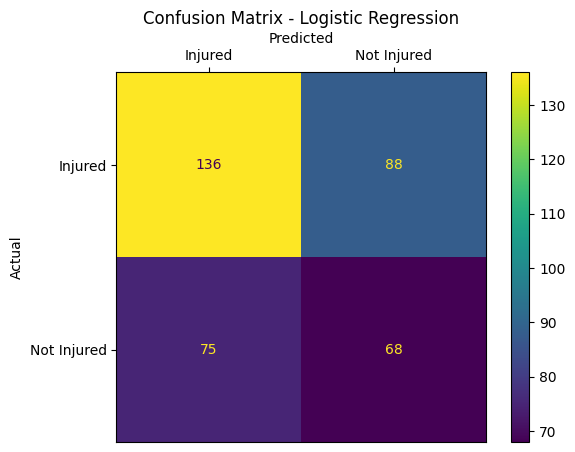

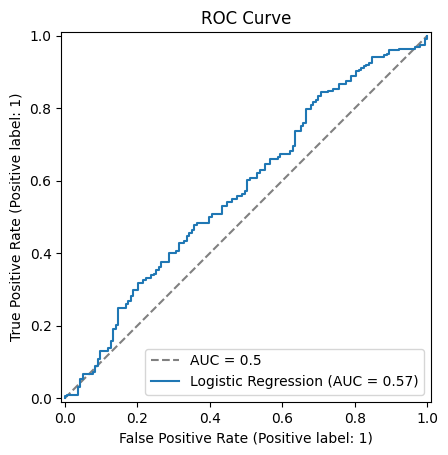

<Figure size 640x480 with 0 Axes>

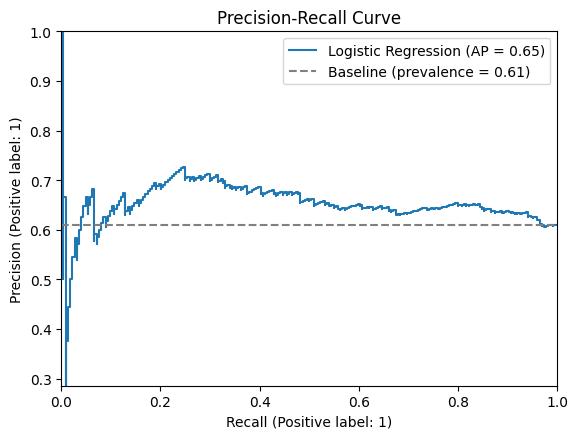

<Figure size 640x480 with 0 Axes>

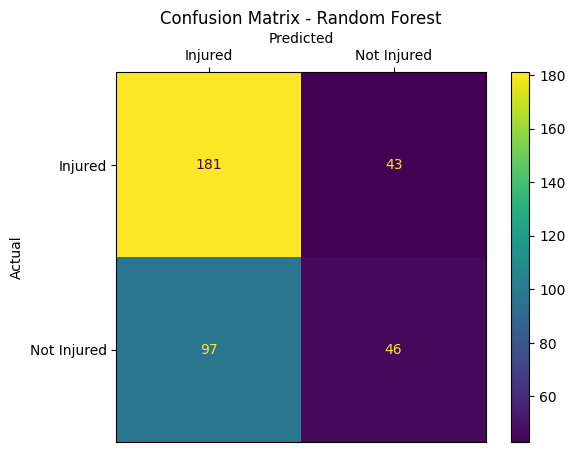

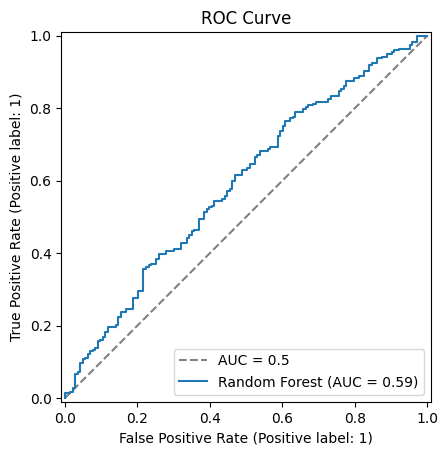

<Figure size 640x480 with 0 Axes>

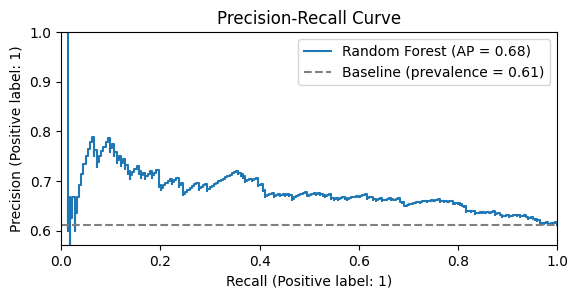

<Figure size 640x480 with 0 Axes>

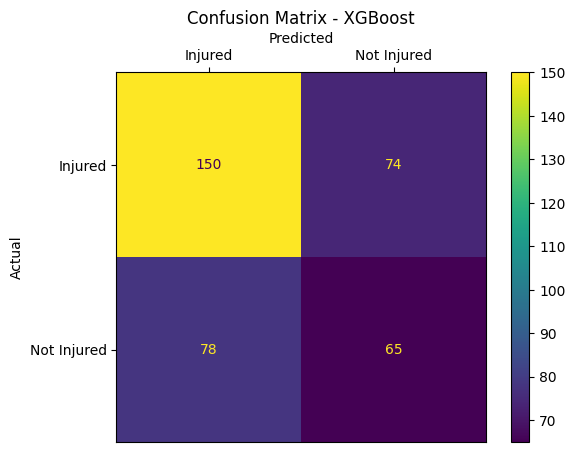

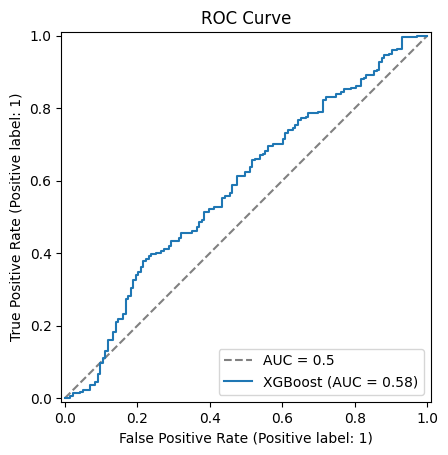

<Figure size 640x480 with 0 Axes>

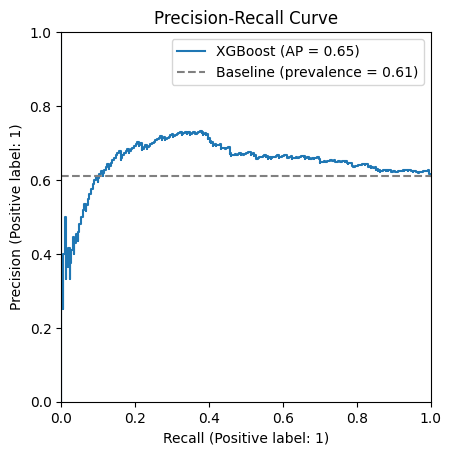

<Figure size 640x480 with 0 Axes>

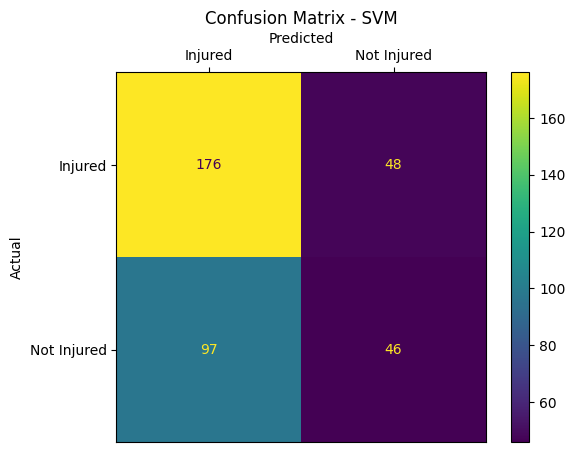

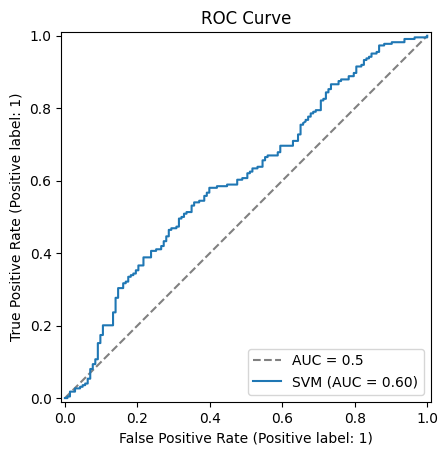

<Figure size 640x480 with 0 Axes>

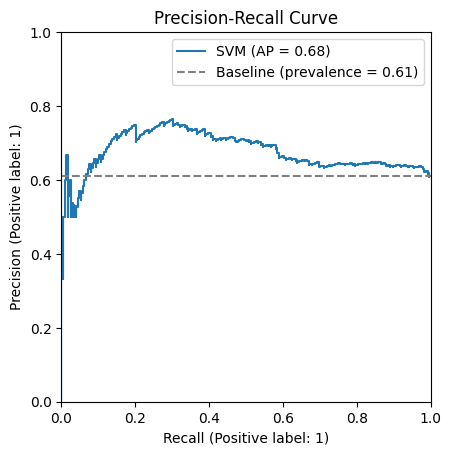

In [7]:
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print()


for model_name, model in trained_models.items():
    print('\n' + '='*50)
    print(f"Model: {model_name}")
    best_threshold = results[model_name]['best_threshold']
    pred = SklearnAPIPredictor(model)
    test_summary = model_test_summary(model, X_test, y_test,
        threshold=best_threshold,
        predictor=pred,
        model_name=model_name,
        save_predictions=True,
    )
    
    results[model_name].update(test_summary)

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test PR AUC  Test Accuracy  \
3                  SVM        0.6036       0.6751         0.6049   
1        Random Forest        0.5914       0.6815         0.6185   
2              XGBoost        0.5824       0.6489         0.5858   
0  Logistic Regression        0.5737       0.6548         0.5559   

   Test Precision  Test Recall  Test F1-Score  Test Prevalence  Test Threshold  
3          0.6447       0.7857         0.5482           0.6104          0.4689  
1          0.6511       0.8080         0.5588           0.6104          0.4952  
2          0.6579       0.6696         0.5624           0.6104          0.7361  
0          0.6445       0.6071         0.5401           0.6104          0.4523  

Best performing model: SVM
Best Test ROC AUC Score: 0.6036


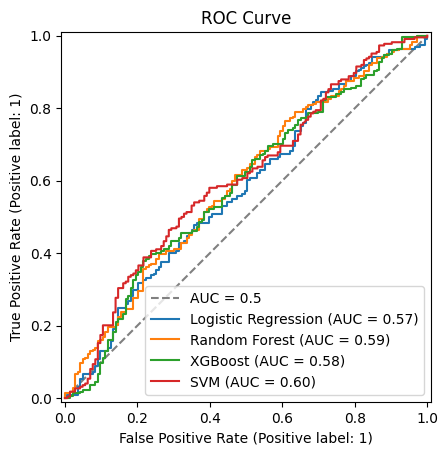

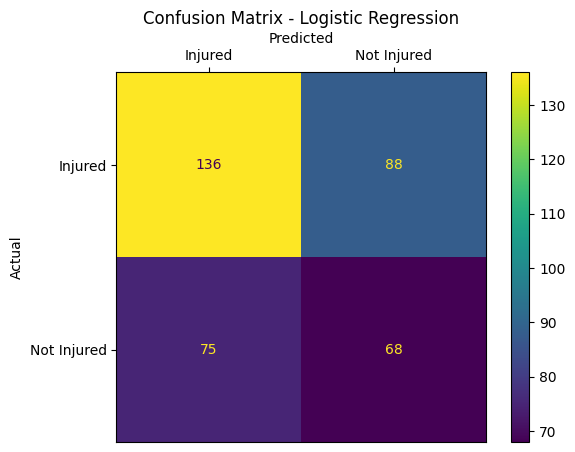

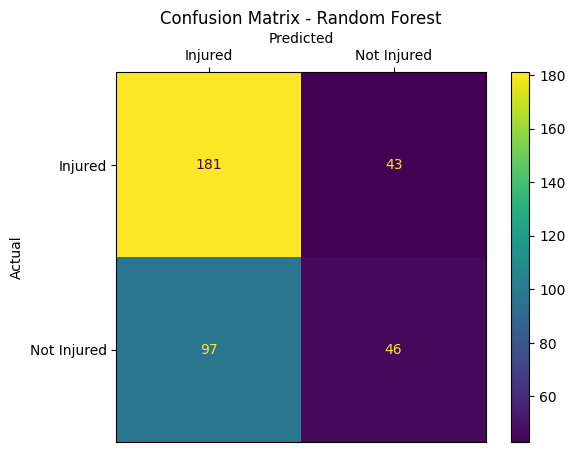

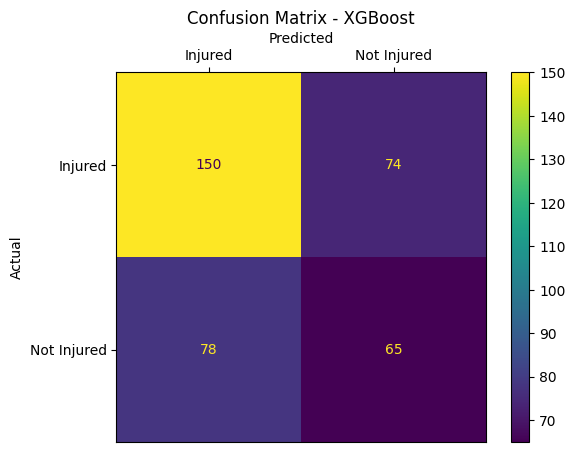

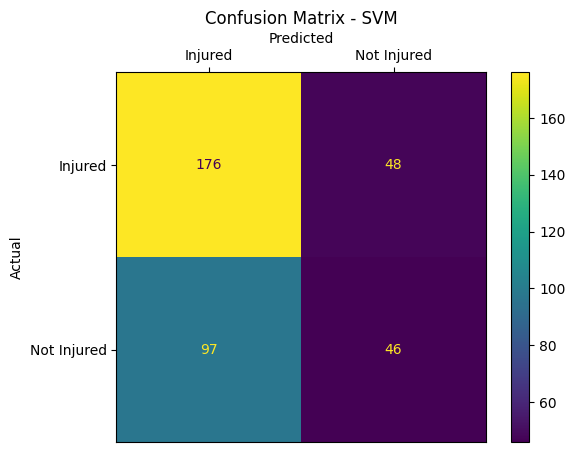

In [8]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['auc_roc'],
        'Test PR AUC': result['auc_pr'],
        'Test Accuracy': result['accuracy'],
        'Test Precision': result['precision'],
        'Test Recall': result['recall'],
        'Test F1-Score': result['f1'],
        'Test Prevalence': result['prevalence'],
        'Test Threshold': result['threshold'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")

In [9]:
import pickle
from pathlib import Path

if SAVE_MODEL:
    folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
    folder_path.mkdir(parents=True, exist_ok=True)

    with open(f"{folder_path}/results.pkl", "wb") as f:
        pickle.dump(results, f)
